<a href="https://colab.research.google.com/github/azrapatvi/dl-practice/blob/main/9_drop_out.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
X_train = np.linspace(-1, 1, 20)

In [ ]:
y_train = np.array([-0.6561 , -0.3099 , -0.59035, -0.50855, -0.285  ,
                    -0.2443 , -0.02445,  0.00135, -0.2006 ,  0.07475,
                    -0.1422 ,  0.06515,  0.15265,  0.3521 ,  0.28415,
                    0.5524 ,  0.23115,  0.20835, 0.4211,  0.60485])

In [ ]:
X_test = np.linspace(-1, 1, 20)

In [ ]:
y_test = np.array([-0.69415, -0.451  , -0.43005, -0.4484 , -0.1475 ,
                   -0.5019 , -0.28055,  0.24595, -0.21425, -0.0286 ,
                   0.23415,  0.46575, 0.07955,  0.1973 ,  0.0719 ,
                   0.3639 ,  0.5536 ,  0.3365 , 0.50705,  0.33435])

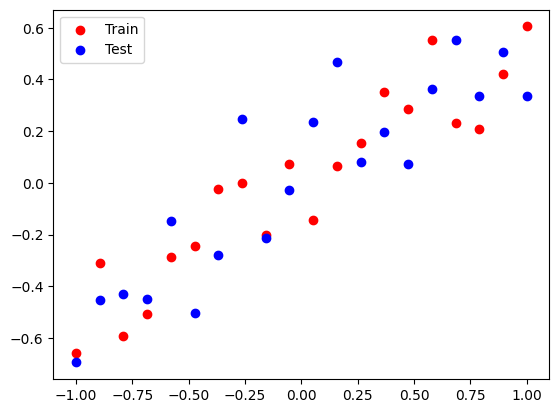

In [ ]:
plt.scatter(X_train, y_train, c='red', label='Train')
plt.scatter(X_test, y_test, c='blue', label='Test')
plt.legend()
plt.show()

In [ ]:
y_train

array([-0.6561 , -0.3099 , -0.59035, -0.50855, -0.285  , -0.2443 ,
       -0.02445,  0.00135, -0.2006 ,  0.07475, -0.1422 ,  0.06515,
        0.15265,  0.3521 ,  0.28415,  0.5524 ,  0.23115,  0.20835,
        0.4211 ,  0.60485])

In [ ]:
X_train

array([-1.        , -0.89473684, -0.78947368, -0.68421053, -0.57894737,
       -0.47368421, -0.36842105, -0.26315789, -0.15789474, -0.05263158,
        0.05263158,  0.15789474,  0.26315789,  0.36842105,  0.47368421,
        0.57894737,  0.68421053,  0.78947368,  0.89473684,  1.        ])

In [ ]:
X_train.shape

(20,)

In [ ]:
# without dropout

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

model=Sequential([
    Dense(128,activation='relu',input_dim=1),
    Dense(128,activation='relu'),
    Dense(1,activation='linear')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,897 (66.00 KB)

 Trainable params: 16,897 (66.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='mse',metrics=['mae'])

In [ ]:
history=model.fit(X_train,y_train,epochs=500,verbose=1,validation_data=(X_test,y_test))

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.1088 - mae: 0.2761 - val_loss: 0.0945 - val_mae: 0.2671
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.0839 - mae: 0.2419 - val_loss: 0.0738 - val_mae: 0.2325
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 0.0637 - mae: 0.2088 - val_loss: 0.0578 - val_mae: 0.2027
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 0.0480 - mae: 0.1793 - val_loss: 0.0460 - val_mae: 0.1771
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0364 - mae: 0.1551 - val_loss: 0.0377 - val_mae: 0.1547
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0283 - mae: 0.1357 - val_loss: 0.0324 - val_mae: 0.1375
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0231 - mae: 0.1268 - val_loss: 0.0295 - val_mae: 0.1313
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0203 - mae: 0.1215 - val_loss: 0.0285 - val_mae: 0.1289
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0193 - mae:

In [ ]:
# evaluate the model
_, train_mse = model.evaluate(X_train, y_train, verbose=0)
_, test_mse = model.evaluate(X_test, y_test, verbose=0)
print('Train: {}, Test: {}'.format(train_mse, test_mse))

Train: 0.06939031183719635, Test: 0.15298357605934143


In [ ]:
train_mse-test_mse

-0.08359326422214508

In [ ]:
y_pred_1 = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


In [ ]:
y_pred_1

array([[-0.58786416],
       [-0.5335878 ],
       [-0.47931144],
       [-0.42503217],
       [-0.31386045],
       [-0.20134166],
       [-0.08882284],
       [-0.00245425],
       [-0.19802275],
       [ 0.07275014],
       [-0.13479702],
       [ 0.04221851],
       [ 0.18435195],
       [ 0.3242655 ],
       [ 0.33581284],
       [ 0.34705612],
       [ 0.35829934],
       [ 0.3721821 ],
       [ 0.43703786],
       [ 0.50189364]], dtype=float32)

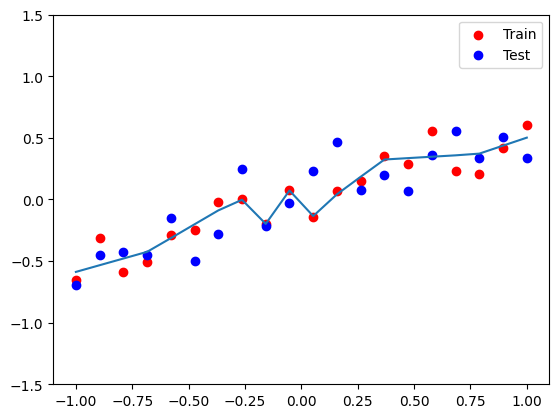

In [ ]:
plt.figure()
plt.scatter(X_train, y_train, c='red', label='Train')
plt.scatter(X_test, y_test, c='blue', label='Test')
plt.plot(X_test, y_pred_1)
plt.legend()
plt.ylim((-1.5, 1.5))
plt.show()

In [ ]:
#with dropout
from tensorflow.keras.layers import Dropout

model=Sequential([
    Dense(128,activation='relu',input_dim=1),
    Dropout(0.2),
    Dense(128,activation='relu'),
    Dropout(0.2),
    Dense(1,activation='linear')
])

In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,897 (66.00 KB)

 Trainable params: 16,897 (66.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='mse',metrics=['mae'])

In [ ]:
history=model.fit(X_train,y_train,epochs=500,verbose=1,validation_data=(X_test,y_test))

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 882ms/step - loss: 0.1175 - mae: 0.2811 - val_loss: 0.1034 - val_mae: 0.2802
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0866 - mae: 0.2485 - val_loss: 0.0833 - val_mae: 0.2471
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.0838 - mae: 0.2302 - val_loss: 0.0667 - val_mae: 0.2175
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0593 - mae: 0.1923 - val_loss: 0.0535 - val_mae: 0.1935
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0464 - mae: 0.1723 - val_loss: 0.0435 - val_mae: 0.1721
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0469 - mae: 0.1703 - val_loss: 0.0362 - val_mae: 0.1552
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0305 - mae: 0.1433 - val_loss: 0.0317 - val_mae: 0.1415
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0270 - mae: 0.1370 - val_loss: 0.0295 - val_mae: 0.1337
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0206 - mae:

In [ ]:
# evaluate the model
_, train_mse = model.evaluate(X_train, y_train, verbose=0)
_, test_mse = model.evaluate(X_test, y_test, verbose=0)
print('Train: {}, Test: {}'.format(train_mse, test_mse))

Train: 0.09673329442739487, Test: 0.14682671427726746


In [ ]:
train_mse-test_mse

-0.05009341984987259

In [ ]:
y_pred_1 = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


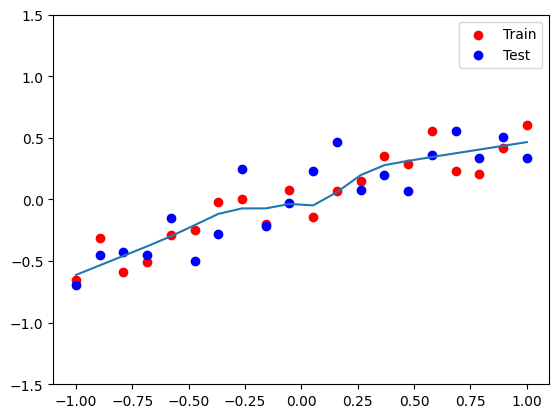

In [ ]:
plt.figure()
plt.scatter(X_train, y_train, c='red', label='Train')
plt.scatter(X_test, y_test, c='blue', label='Test')
plt.plot(X_test, y_pred_1)
plt.legend()
plt.ylim((-1.5, 1.5))
plt.show()